# 02 · Feature Engineering
**Project:** Eco-Urbanomics — Vehicle CO2 Emissions  
**Goal:** Parse and encode categoricals, extract transmission metadata, engineer interaction features, scale, and save `processed_co2_data.csv`.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from pathlib import Path
import re, warnings
warnings.filterwarnings('ignore')

RAW       = Path('../data/raw/CO2_Emissions_Canada.csv')
PROCESSED = Path('../data/processed/processed_co2_data.csv')
PROCESSED.parent.mkdir(parents=True, exist_ok=True)
OUT_IMG   = Path('../data/outputs')

df = pd.read_csv(RAW)
print(f"Loaded: {df.shape}")
df.head()


Loaded: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [9]:
# ── 1. Define target variables ─────────────────────────────────────────
THRESHOLD = df['CO2 Emissions(g/km)'].quantile(0.70)
df['High_Emitter'] = (df['CO2 Emissions(g/km)'] >= THRESHOLD).astype(int)
print(f"Target threshold (P70): {THRESHOLD:.0f} g/km")
print(f"High_Emitter distribution:\n{df['High_Emitter'].value_counts()}")


Target threshold (P70): 278 g/km
High_Emitter distribution:
High_Emitter
0    5140
1    2245
Name: count, dtype: int64


In [10]:
# ── 2. Drop Model (2,053 unique values — too sparse) ──────────────────
df = df.drop(columns=['Model'])
print("Dropped 'Model' column.")
print(f"Shape after drop: {df.shape}")


Dropped 'Model' column.
Shape after drop: (7385, 12)


In [11]:
# ── 3. Parse Transmission ──────────────────────────────────────────────
# Transmission codes: e.g. AS6 → Automatic, 6 gears
#                         M6  → Manual, 6 gears
#                         AV  → Automatic CVT (variable — assign 0)
#                         AM7 → Automated Manual, 7 gears

def parse_trans_type(t):
    """Return 1=Automatic, 0=Manual"""
    return 0 if str(t).startswith('M') else 1

def parse_num_gears(t):
    """Extract gear count from transmission code; 0 for CVT"""
    nums = re.findall(r'\d+', str(t))
    return int(nums[0]) if nums else 0

df['Trans_Type']  = df['Transmission'].apply(parse_trans_type)
df['Num_Gears']   = df['Transmission'].apply(parse_num_gears)

print("Transmission parsed:")
print(df[['Transmission','Trans_Type','Num_Gears']].drop_duplicates().head(12).to_string(index=False))


Transmission parsed:
Transmission  Trans_Type  Num_Gears
         AS5           1          5
          M6           0          6
         AV7           1          7
         AS6           1          6
         AM6           1          6
          A6           1          6
         AM7           1          7
         AV8           1          8
         AS8           1          8
          A7           1          7
          A8           1          8
          M7           0          7


In [12]:
# ── 4. Encode Fuel Type (one-hot, drop_first) ─────────────────────────
# X=Regular Gas, Z=Premium Gas, E=Ethanol E85, D=Diesel, N=Natural Gas
fuel_dummies = pd.get_dummies(df['Fuel Type'], prefix='Fuel', drop_first=True)
print("Fuel Type dummies:")
print(fuel_dummies.sum())
df = pd.concat([df, fuel_dummies], axis=1)


Fuel Type dummies:
Fuel_E     370
Fuel_N       1
Fuel_X    3637
Fuel_Z    3202
dtype: int64


In [13]:
# ── 5. Label-encode Make and Vehicle Class ────────────────────────────
le_make = LabelEncoder()
le_vc   = LabelEncoder()

df['Make_Enc']         = le_make.fit_transform(df['Make'])
df['Vehicle_Class_Enc'] = le_vc.fit_transform(df['Vehicle Class'])

print(f"Make encoded: {df['Make_Enc'].nunique()} classes")
print(f"Vehicle Class encoded: {df['Vehicle_Class_Enc'].nunique()} classes")


Make encoded: 42 classes
Vehicle Class encoded: 16 classes


In [14]:
# ── 6. Engineer interaction features ──────────────────────────────────
# 6a. City-Highway Ratio: >1 means heavy city driving (higher emissions)
df['City_Hwy_Ratio'] = (
    df['Fuel Consumption City (L/100 km)'] /
    (df['Fuel Consumption Hwy (L/100 km)'] + 1e-6)
)

# 6b. Displacement per Cylinder: larger = more powerful per cylinder
df['Displacement_per_Cyl'] = df['Engine Size(L)'] / (df['Cylinders'] + 1e-6)

# 6c. Fuel Efficiency Score: inverse of combined L/100km (higher = greener)
df['Fuel_Efficiency_Score'] = 1.0 / (df['Fuel Consumption Comb (L/100 km)'] + 1e-6)

# 6d. Engine Load Index: engine size × cylinders (proxy for raw power demand)
df['Engine_Load_Index'] = df['Engine Size(L)'] * df['Cylinders']

# 6e. Green Score: mpg × fuel efficiency score (composite environmental index)
df['Green_Score'] = df['Fuel Consumption Comb (mpg)'] * df['Fuel_Efficiency_Score']

new_feats = ['City_Hwy_Ratio','Displacement_per_Cyl',
             'Fuel_Efficiency_Score','Engine_Load_Index','Green_Score']
print("Engineered features preview:")
print(df[new_feats].describe().T[['mean','std','min','max']].round(4))


Engineered features preview:
                          mean      std     min       max
City_Hwy_Ratio          1.3812   0.1276  0.8571    1.8211
Displacement_per_Cyl    0.5487   0.0938  0.2500    0.8500
Fuel_Efficiency_Score   0.0974   0.0256  0.0383    0.2439
Engine_Load_Index      20.0403  15.3559  2.7000  128.0000
Green_Score             2.8607   1.6258  0.4215   16.8293


In [15]:
# ── 7. Assemble final feature matrix ──────────────────────────────────
fuel_dummy_cols = [c for c in df.columns if c.startswith('Fuel_')]

FEATURE_COLS = [
    # Raw numeric
    'Engine Size(L)', 'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Comb (mpg)',
    # Parsed transmission
    'Trans_Type', 'Num_Gears',
    # Encoded categoricals
    'Make_Enc', 'Vehicle_Class_Enc',
    # Fuel type dummies
] + fuel_dummy_cols + [
    # Engineered features
    'City_Hwy_Ratio', 'Displacement_per_Cyl',
    'Fuel_Efficiency_Score', 'Engine_Load_Index', 'Green_Score'
]

TARGET_CLASS = 'High_Emitter'
TARGET_REG   = 'CO2 Emissions(g/km)'

print(f"Total features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Total features: 20
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'Trans_Type', 'Num_Gears', 'Make_Enc', 'Vehicle_Class_Enc', 'Fuel_E', 'Fuel_N', 'Fuel_X', 'Fuel_Z', 'Fuel_Efficiency_Score', 'City_Hwy_Ratio', 'Displacement_per_Cyl', 'Fuel_Efficiency_Score', 'Engine_Load_Index', 'Green_Score']


In [16]:
# ── 8. Scale numeric features (exclude binary/encoded categoricals) ───
# We scale all continuous features; binary and label-encoded stay as-is
SCALE_COLS = [
    'Engine Size(L)', 'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
    'Fuel Consumption Comb (mpg)',
    'Num_Gears',
    'City_Hwy_Ratio', 'Displacement_per_Cyl',
    'Fuel_Efficiency_Score', 'Engine_Load_Index', 'Green_Score'
]

scaler = StandardScaler()
df_out = df[FEATURE_COLS + [TARGET_REG, TARGET_CLASS]].copy()
df_out[SCALE_COLS] = scaler.fit_transform(df_out[SCALE_COLS])

print("Post-scaling means (should be ~0):")
print(df_out[SCALE_COLS].mean().round(3))
print("\nPost-scaling stds (should be ~1):")
print(df_out[SCALE_COLS].std().round(3))


Post-scaling means (should be ~0):
Engine Size(L)                      0.0
Cylinders                           0.0
Fuel Consumption City (L/100 km)    0.0
Fuel Consumption Hwy (L/100 km)    -0.0
Fuel Consumption Comb (L/100 km)    0.0
Fuel Consumption Comb (mpg)        -0.0
Num_Gears                          -0.0
City_Hwy_Ratio                     -0.0
Displacement_per_Cyl               -0.0
Fuel_Efficiency_Score               0.0
Fuel_Efficiency_Score               0.0
Engine_Load_Index                   0.0
Green_Score                         0.0
dtype: float64

Post-scaling stds (should be ~1):
Engine Size(L)                      1.0
Cylinders                           1.0
Fuel Consumption City (L/100 km)    1.0
Fuel Consumption Hwy (L/100 km)     1.0
Fuel Consumption Comb (L/100 km)    1.0
Fuel Consumption Comb (mpg)         1.0
Num_Gears                           1.0
City_Hwy_Ratio                      1.0
Displacement_per_Cyl                1.0
Fuel_Efficiency_Score              

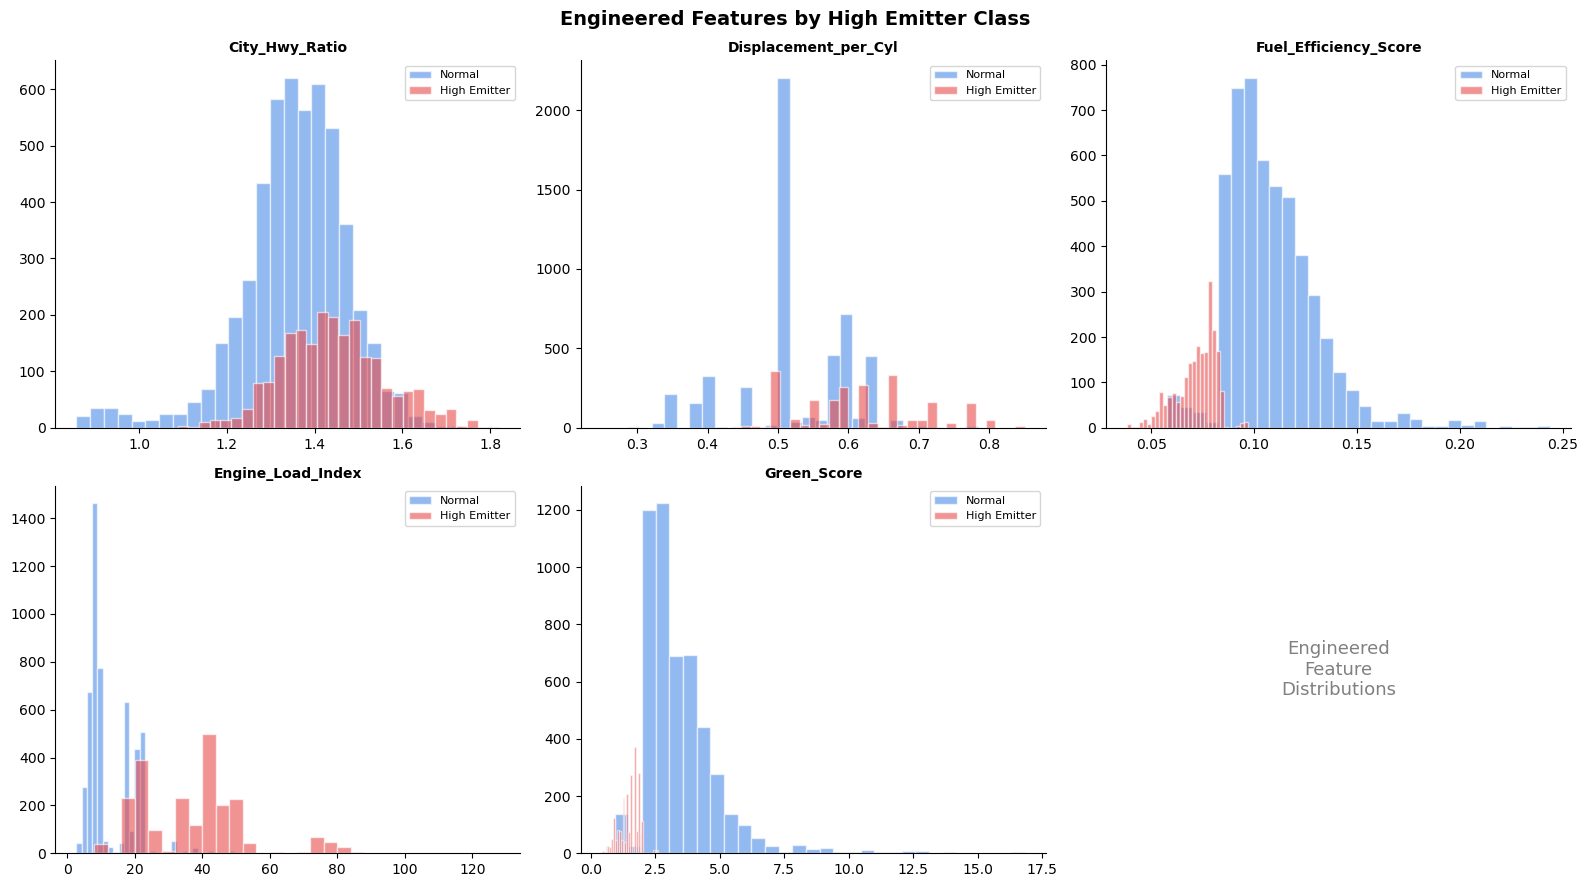

In [17]:
# ── 9. Visualise engineered features ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
original_df = df.copy()  # use pre-scaled for interpretable plots

for i, feat in enumerate(new_feats):
    for flag, color, label in [(0,'#4C8BE8','Normal'), (1,'#E84C4C','High Emitter')]:
        axes[i].hist(original_df[original_df[TARGET_CLASS]==flag][feat],
                     bins=30, alpha=0.6, color=color,
                     label=label, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].spines[['top','right']].set_visible(False)

axes[5].axis('off')
axes[5].text(0.5, 0.5, 'Engineered\nFeature\nDistributions',
             ha='center', va='center', fontsize=13, color='grey')

plt.suptitle('Engineered Features by High Emitter Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_IMG / 'fe_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ── 10. Save processed CSV ────────────────────────────────────────────
df_out.to_csv(PROCESSED, index=False)
print(f"Saved → {PROCESSED}")
print(f"Shape : {df_out.shape}")
print(f"Columns: {df_out.columns.tolist()}")


Saved → ..\data\processed\processed_co2_data.csv
Shape : (7385, 22)
Columns: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'Trans_Type', 'Num_Gears', 'Make_Enc', 'Vehicle_Class_Enc', 'Fuel_E', 'Fuel_N', 'Fuel_X', 'Fuel_Z', 'Fuel_Efficiency_Score', 'City_Hwy_Ratio', 'Displacement_per_Cyl', 'Fuel_Efficiency_Score', 'Engine_Load_Index', 'Green_Score', 'CO2 Emissions(g/km)', 'High_Emitter']
